In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.stats import binom
from scipy.stats import gamma
from scipy.stats import norm

with open("3.data",'r') as f:
        data=np.loadtxt(f)

### Task A

In [2]:
def ith_moment(dataset,i):
    return np.sum(np.power(dataset,i))/len(dataset)

moment1=ith_moment(data,1)
moment2=ith_moment(data,2)
print(f"First Moment: {moment1} , Second Moment: {moment2}")

First Moment: 6.496145618324817 , Second Moment: 46.554361807879815


### Task B

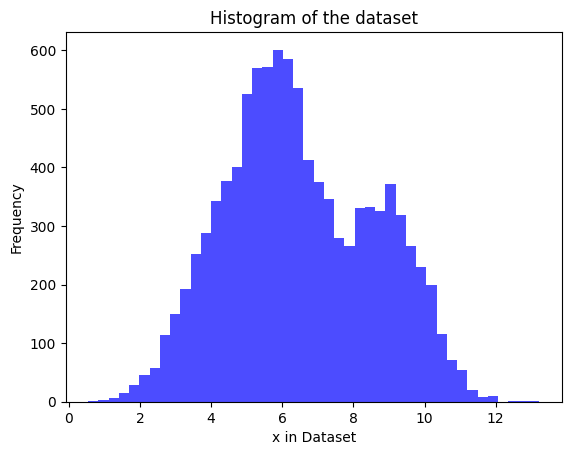

In [3]:
plt.hist(data, bins='auto', color='blue', label='Histogram', alpha=0.7)
plt.xlabel("x in Dataset")
plt.ylabel("Frequency")
plt.title("Histogram of the dataset")   
plt.savefig("images/3b.png")
plt.show()

Graphially, the normal distribution parameter from the histogram seems to somewhat around 6.

### Task C

In [4]:
def eq_bin(params):
    n, p=params
    exp_moment1 = n*p
    exp_moment2 = n*p*(1-p) + n*n*p*p
    return [exp_moment1-moment1,exp_moment2-moment2]

initial_guess_bin=[1,1]

n_bin, p_bin=fsolve(eq_bin,initial_guess_bin)
print(f"n = {n_bin} , p = {p_bin}")

n = 19.70400678930485 , p = 0.32968652963756756


After analysing both n=19 and n=20, n=20 is the better and more precise solution

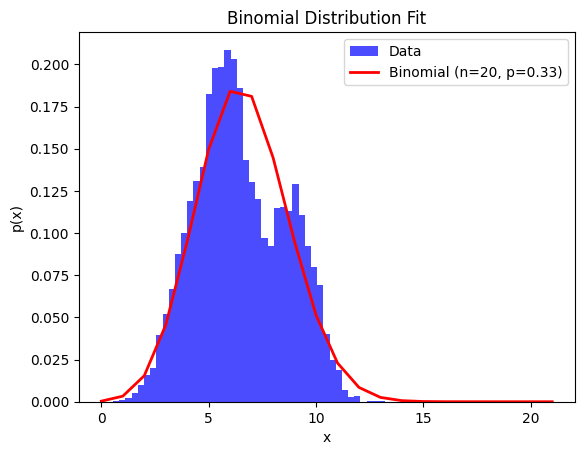

In [5]:
n,p=20,p_bin 

x = np.linspace(0, n+1, n+2)

# Plot histogram and PMF
plt.hist(data, bins='auto', density=True, color='blue', label='Data', alpha=0.7)
binom_pmf = binom.pmf(x, n, p)
plt.plot(x, binom_pmf, 'r-', lw=2, label=f'Binomial (n={n}, p={p:.2f})')

plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Binomial Distribution Fit')
plt.legend(loc='upper right')
plt.savefig("images/3c.png")
plt.show()

### Task D

In [6]:
def eq_gamma(params):
    k,theta=params
    exp_moment1=k*theta
    exp_moment2=k * (k+ 1) * theta**2
    
    return [exp_moment1-moment1, exp_moment2-moment2]

initial_guess_gamma=[1,1]

k_gam, theta_gam=fsolve(eq_gamma,initial_guess_gamma)
print(k_gam,theta_gam)

9.691205541246163 0.6703134703624323


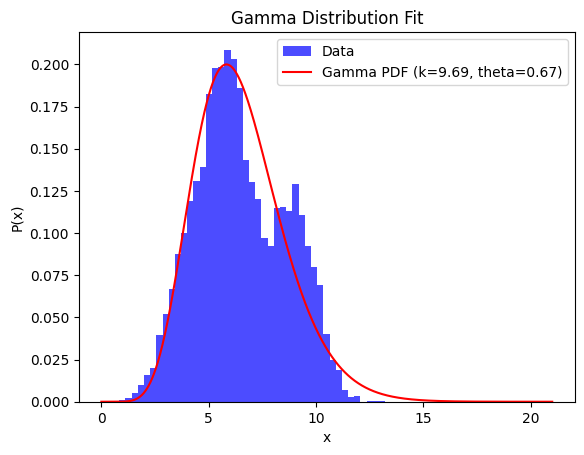

In [7]:
x = np.linspace(0, n+1, 10000)

plt.hist(data, bins='auto', density=True, color='blue', label='Data', alpha=0.7)
gamma_pdf = gamma.pdf(x, k_gam, scale=theta_gam)
plt.plot(x, gamma_pdf, color='red', label=f"Gamma PDF (k={k_gam:.2f}, theta={theta_gam:.2f})")
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Gamma Distribution Fit')
plt.legend(loc='upper right')
plt.savefig("images/3d.png")
plt.show()

### Task E

In [8]:
def average_log_likelihood_binomial(data, n, p):
    data_modified = np.round(data)
    likelihoods = binom.pmf(data_modified, n, p)
    log_likelihoods = np.log(likelihoods)
    average_log_likelihood = np.mean(log_likelihoods)
    return average_log_likelihood

def average_log_likelihood_gamma(data, k, theta):
    likelihoods = gamma.pdf(data, k, scale=theta)
    log_likelihoods = np.log(likelihoods)
    average_log_likelihood = np.mean(log_likelihoods)
    return average_log_likelihood

avg_like_bin=average_log_likelihood_binomial(data,n,p)
avg_like_gamma=average_log_likelihood_gamma(data,k_gam,theta_gam)
print(f"avg LL for binomial: {avg_like_bin}, for gamma: {avg_like_gamma}")

avg LL for binomial: -2.157068115434677, for gamma: -2.160821772206795


Both the fits have almost similar average log likelihood, however binomial is a slightly better fit than gamma fit

### Task F

In [9]:
#step 1: calculating third and forth moments
moment3=ith_moment(data,3)
moment4=ith_moment(data,4)
print(f"3rd moment: {moment3} , 4th moment: {moment4}")

3rd moment: 360.56586952543273 , 4th moment: 2968.068491427333


In [10]:
def eq_GMM(x):
    mu1,p1,mu2,p2=x
    
    exp_moment1 = p1 * mu1 + p2 * mu2
    exp_moment2 = p1 * (1.00 + mu1**2) + p2 * (1.00 + mu2**2)
    exp_moment3 = p1 * (mu1**3 + 3 * mu1) + p2 * (mu2**3 + 3 * mu2)
    exp_moment4 = p1 * (mu1**4 + 6 * (mu1**2) + 3.00) + p2 * (mu2**4 + 6 * (mu2**2) + 3.00)
    
    return [exp_moment1-moment1,exp_moment2-moment2,exp_moment3-moment3,exp_moment4-moment4]

initial_guesses = [6,0,9,0]

mu1,p1,mu2,p2 = fsolve(eq_GMM,initial_guesses)
print(f"p1 = {p1}, mu1 = {mu1}, p2 = {p2}, mu2 = {mu2}")

p1 = 0.6118740341610936, mu1 = 5.129607694285282, p2 = 0.3826456511927248, mu2 = 8.77436305441652


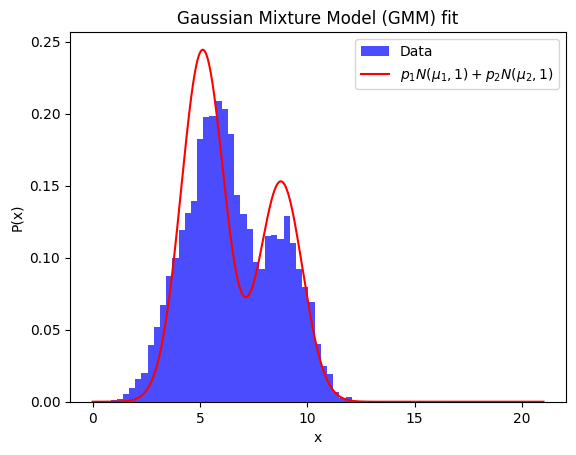

In [11]:
#Plotting GMM
x = np.linspace(0, n+1, 10000)
pdf1 = norm.pdf(x, mu1, 1)  
pdf2 = norm.pdf(x, mu2, 1) 
gmm_pdf = p1 * pdf1 + p2 * pdf2  # the overall GMM PDF

# Plot the GMM PDF and sample data
plt.hist(data, bins='auto', density=True, color='blue', label='Data', alpha=0.7)
plt.plot(x, gmm_pdf, color='red', label=r'$p_1 N(\mu_1, 1) + p_2 N(\mu_2, 1)$')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Gaussian Mixture Model (GMM) fit')
plt.legend(loc='upper right')
plt.savefig('images/3f.png')
plt.show()

In [12]:
def average_log_likelihood_GMM(data, p1,mu1,p2,mu2):
    pdf1 = norm.pdf(data, mu1, 1)  
    pdf2 = norm.pdf(data, mu2, 1) 
    gmm_probs = p1 * pdf1 + p2 * pdf2 
    log_likelihoods = np.log(gmm_probs)
    average_log_likelihood = np.mean(log_likelihoods)
    return average_log_likelihood

print(f"avg LL for GMM: {average_log_likelihood_GMM(data,p1,mu1,p2,mu2)}")

avg LL for GMM: -2.1830387449113196


### Bonus part:

In order to get a better fit, lets choose again a mixture of guassian distribution. The difference from previous case is that instead of two guassian, lets take three distribution superimposed over each other with probabilities p1, p2 and p3 , mean as μ1, μ2 and μ3 and variance of all of them as 1.

In [13]:
moment5=ith_moment(data,5)
moment6=ith_moment(data,6)

def eq_GMM2(params):
    mu1,p1,mu2,p2,mu3,p3=params
    
    exp_moment1 = p1 * mu1 + p2 * mu2 +p3*mu3
    exp_moment2 = p1 * (1.00 + mu1**2) + p2 * (1.00 + mu2**2) + p3 * (1.00 + mu3**2)
    exp_moment3 = p1 * (mu1**3 + 3 * mu1) + p2 * (mu2**3 + 3 * mu2) + p3 * (mu3**3 + 3 * mu3)
    exp_moment4 = p1 * (mu1**4 + 6 * (mu1**2) + 3.00) + p2 * (mu2**4 + 6 * (mu2**2) + 3.00) + p3 * (mu3**4 + 6 * (mu3**2) + 3.00)
    exp_moment5 = p1*(mu1**5 + 10*mu1**3+15) + p2*(mu2**5 + 10*mu2**3+15)+ p3*(mu3**5 + 10*mu3**3+15)
    exp_moment6 = p1*(mu1**6 + 15*mu1**4+45*mu1**2+15)+p2*(mu2**6 + 15*mu2**4+45*mu2**2+15)+ p3*(mu3**6 + 15*mu3**4+45*mu3**2+15)
    
    return [exp_moment1-moment1,exp_moment2-moment2,exp_moment3-moment3,exp_moment4-moment4,exp_moment5-moment5,exp_moment6-moment6]

initial_guesses = [6,0.5,9,0.3,4.1,0.2]

mu1,p1,mu2,p2,mu3,p3 = fsolve(eq_GMM2,initial_guesses)
print(f"p1 = {p1}, mu1 = {mu1}, p2 = {p2}, mu2 = {mu2}, p3={p3}, mu3={mu3}")


p1 = 0.9674874836205982, mu1 = 5.281966742679565, p2 = 0.29046014868287, mu2 = 9.110922520033713, p3=-0.23830160118461216, mu3=3.5754415357349836


/tmp/ipykernel_39428/4151553948.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  mu1,p1,mu2,p2,mu3,p3 = fsolve(eq_GMM2,initial_guesses)


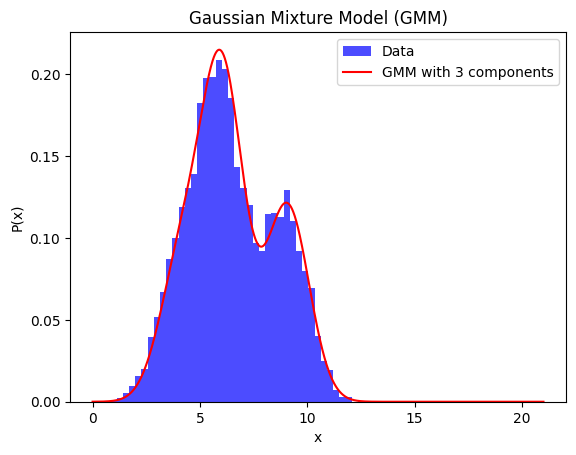

In [14]:

#Obtained by hypertuning the parameters
p1 = 0.5018740341610936  
mu1 = 6.02960769428528
p2 = 0.2996456511927248
mu2 = 9.07436305441652
p3=0.2
mu3=4.1

#Plotting GMM
x = np.linspace(0, n+1, 10000)
pdf1 = norm.pdf(x, mu1, 1)  
pdf2 = norm.pdf(x, mu2, 1) 
pdf3 = norm.pdf(x, mu3, 1)
gmm2_pdf = p1 * pdf1 + p2 * pdf2 + p3* pdf3

# Plot the GMM PDF and sample data
plt.hist(data, bins='auto', density=True, color='blue', label='Data', alpha=0.7)
plt.plot(x, gmm2_pdf, color='red', label=r'GMM with 3 components')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Gaussian Mixture Model (GMM)')
plt.legend(loc='upper right')
plt.savefig('images/3bonus.png')
plt.show()